## Pydantic - Data Validation

In [1]:
from typing_extensions import TypedDict

class State(TypedDict):
    xyz:str
    abc:str

In [2]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

from pydantic import BaseModel


# The overall state of the graph (this is the public state shared across nodes)
class OverallState(BaseModel):
    a: str

def node(state:OverallState):
    return {"a":"Hi I am Krish"}

In [3]:
# Build the state graph
builder = StateGraph(OverallState)
builder.add_node(node)  # node_1 is the first node
builder.add_edge(START, "node")  # Start the graph with node_1
builder.add_edge("node", END)  # End the graph after node_1
graph = builder.compile()

In [4]:
graph.invoke({"a":"Hello"})

{'a': 'Hi I am Krish'}

In [5]:
try:
    graph.invoke({"a":123})  #should be a string
except Exception as e:
    print("Exception was raised because a value iss integer")

## Multiple Nodes- Run time validation

Run-time validation will also work in a multi-node graph. In the example below bad_node updates a to an integer.

Because run-time validation occurs on inputs, the validation error will occur when ok_node is called (not when bad_node returns an update to the state which is inconsistent with the schema).

In [6]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from pydantic import BaseModel

class OverallState(BaseModel):
    a:str
    
def bad_node(stare: OverallState):
    return {
        "a": 123  # This should be a string, but it's an integer
    }
    
def ok_node(state:OverallState):
    return { "a":"goodbye"}


# builder the state graph
builder = StateGraph(OverallState)
builder.add_node(bad_node)  # This node will raise an error 
builder.add_node(ok_node)  # This node will not be reached
builder.add_edge(START, "bad_node")  # Start the graph with bad_node
builder.add_edge("bad_node", "ok_node")  # Connect to ok_node
builder.add_edge("ok_node", END)  # End the graph after ok_node
graph = builder.compile()

In [7]:
graph.invoke({"a":"Hello"})

{'a': 'goodbye'}

In [8]:
# Test the graph with a valid input
try:
    graph.invoke({"a": "krish"})
except Exception as e:
    print("An exception was raised because bad_node sets `a` to an integer.")
    print(e)

### Prompt Chaining
Prompt chaining decomposes a task into a sequence of steps, where each LLM call processes the output of the previous one. You can add programmatic checks on any intermediate steps to ensure that the process is still on track.

When to use this workflow: This workflow is ideal for situations where the task can be easily and cleanly decomposed into fixed subtasks. The main goal is to trade off latency for higher accuracy, by making each LLM call an easier task.

Q-1: Creating a joke generator that generate joke, if pass then __end__  else If fail then, improve joke -> polish joke then __end__

In [9]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="gemma2-9b-it")

In [10]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

In [11]:
# Node
def generate_joke(state: State):
    " First LLM call to generate a joke based on the topic "
    
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    
    return {"joke": msg.content}


def check_punchline(state:State):
    " Gate function to check if the joke's punchline is good enough "
    
    # Does the joke contains ? or !
    if "?" in state['joke'] or "!" in state['joke']:
        return "Fail"
    else:
        return "Pass"
    
    
def improve_joke(state:State):
    "Second LLM call to improve the joke if needed"
    
    msg = llm.invoke(f"Make this joke better by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state:State):
    " Third LLM call to polish the joke "
    
    msg = llm.invoke(f"Add a suprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}

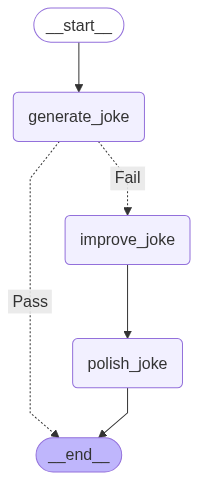

In [12]:
# Build Workflow
workflow = StateGraph(State)

# Add Nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges("generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END})
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show the graph
display(Image(chain.get_graph().draw_mermaid_png()))


In [13]:
# Invoke
state = chain.invoke({
    "topic": "cats"
})

In [14]:
state

{'topic': 'cats',
 'joke': "Why don't cats play poker in the jungle? \n\nToo many cheetahs!  \n",
 'improved_joke': "Why don't cats play poker in the jungle? \n\nToo many **cheetahs** looking to **stake** their claim!  \n\n\nLet me know if you'd like to try another one! 😄 \n",
 'final_joke': "Why don't cats play poker in the jungle? \n\nToo many cheetahs looking to stake their claim!  \n\n**Twist:** ...because the monkeys keep peeking at their cards and going bananas! \n\n\nLet's do another one! 😄  \n"}

In [15]:
state['improved_joke']

"Why don't cats play poker in the jungle? \n\nToo many **cheetahs** looking to **stake** their claim!  \n\n\nLet me know if you'd like to try another one! 😄 \n"

In [16]:
state['final_joke']

"Why don't cats play poker in the jungle? \n\nToo many cheetahs looking to stake their claim!  \n\n**Twist:** ...because the monkeys keep peeking at their cards and going bananas! \n\n\nLet's do another one! 😄  \n"

### Parallelization¶
With parallelization, LLMs work simultaneously on a task:

LLMs can sometimes work simultaneously on a task and have their outputs aggregated programmatically. This workflow, parallelization, manifests in two key variations: Sectioning: Breaking a task into independent subtasks run in parallel. Voting: Running the same task multiple times to get diverse outputs.

When to use this workflow: Parallelization is effective when the divided subtasks can be parallelized for speed, or when multiple perspectives or attempts are needed for higher confidence results. For complex tasks with multiple considerations, LLMs generally perform better when each consideration is handled by a separate LLM call, allowing focused attention on each specific aspect.

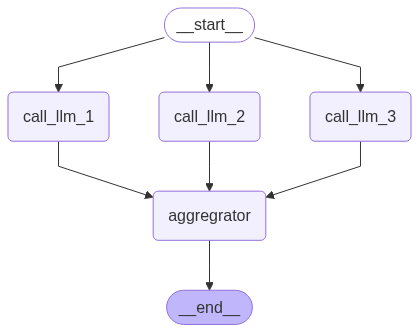

Here's the joke, story, and poem about cats:

STORY:
The rain hammered against the windowpane, a relentless rhythm that mirrored the thrumming in Clementine's chest. She watched the ginger blur disappear into the night, his silhouette swallowed by the storm. 

"Marmalade!" she called, her voice swallowed by the wind.  

He didn't come.

Clementine sighed, her heart sinking. Marmalade, her beloved ginger tabby, had a habit of disappearing. Not maliciously, just…adventurous. He'd stalk butterflies in sunbeams, chase dust bunnies under furniture, and sometimes, he'd simply vanish for hours, returning with a smug air and a muddy paw. 

But this time was different. This time, the storm had come down with a fury, the sky roiling with thunder and lightning. Clementine had seen the flash of a bolt near the oak tree in the backyard, and a primal fear had gripped her.

She paced, the floorboards creaking beneath her feet. She tried calling his name again, but the wind only mocked her with its ho

In [17]:
# Graph State
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str
    
# Node
def call_llm_1(state: State):
    "First LLM call to generate a joke based on the topic"
    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}

def call_llm_2(state: State):
    "Second LLM call to generate a story based on the topic"
    msg = llm.invoke(f"Write a short story based on this topic: {state['topic']}")
    return {"story": msg.content}

def call_llm_3(state: State):
    "Third LLM call to generate a poem based on the topic"
    msg = llm.invoke(f"Write a short poem about {state['topic']}")
    return {"poem": msg.content}


def aggregrator(state:State):
    "Combine the joke, story, and poem into a single output"
    
    combined = f"Here's the joke, story, and poem about {state['topic']}:\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}\n\n"
    return {"combined_output": combined}




# Build Workflow
parallel_builder = StateGraph(State)

# add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregrator", aggregrator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregrator")
parallel_builder.add_edge("call_llm_2", "aggregrator")
parallel_builder.add_edge("call_llm_3", "aggregrator") 
parallel_builder.add_edge("aggregrator", END)
parallel__workflow = parallel_builder.compile()


# Compile the graph
display(Image(parallel__workflow.get_graph().draw_mermaid_png())) 


# Invoke the graph
state = parallel__workflow.invoke({
    "topic": "cats"
})

print(state['combined_output'])
    
    
    

### Routing
Routing classifies an input and directs it to a specialized followup task. This workflow allows for separation of concerns, and building more specialized prompts. Without this workflow, optimizing for one kind of input can hurt performance on other inputs.

When to use this workflow: Routing works well for complex tasks where there are distinct categories that are better handled separately, and where classification can be handled accurately, either by an LLM or a more traditional classification model/algorithm.

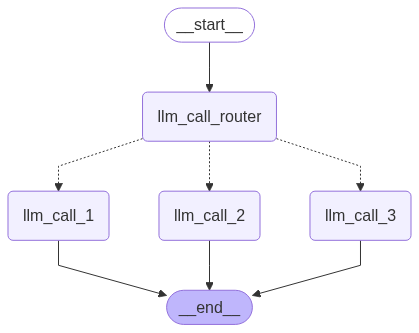

A velvet shadow, sleek and sly,
With eyes that gleam like stars on high.
A silent hunter, quick and light,
A purring rumble, soft and bright.

A flick of tail, a sudden leap,
Across the sunbeam, slumber deep.
A playful paw, a gentle knead,
A feline friend, a heart to feed. 





In [18]:
from typing_extensions import TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage

# Schema for Structured Output to use as routing logic
class Route(BaseModel):
    step: Literal['poem', 'joke', 'story'] = Field(
        description="The next step in the routing process"
    )
    
# Augment the LLM with schema for structued output
router = llm.with_structured_output(Route)

# State
class State(TypedDict):
    input: str
    decision: str
    output: str
    
# Node
def llm_call_1(state: State):
    "Write a story"
    
    result = llm.invoke(state['input'])
    return {"output": result.content}

def llm_call_2(state: State):
    "Write a joke"
    
    result = llm.invoke(state['input'])
    return {"output": result.content}

def llm_call_3(state: State):
    "Write a poem"
    
    result = llm.invoke(state['input'])
    return {"output": result.content}


def llm_call_router(state: State):
    "Route the input to the appropriate Node"
    
    # Run the augmented LLM with structured output to server as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to the story, joke, poem based on the user's input"
                ),
            HumanMessage(content=state['input'])
        ]
    )
    
    return {"decision": decision.step}
    
# Conditional edge function to route to appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    
    if state['decision'] == 'story':
        return "llm_call_1"
    elif state['decision'] == 'joke':
        return "llm_call_2"
    elif state['decision'] == 'poem':   
        return "llm_call_3"
    
    
# Build the workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3"
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile the graph
router_workflow = router_builder.compile()

# Show the graph
display(Image(router_workflow.get_graph().draw_mermaid_png()))

# Invoke the graph
state = router_workflow.invoke({
    "input": "Write a short poem about a cat"
})

print(state['output'])
    
        

### Orchestrator-Worker
In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

When to use this workflow: This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

In [19]:
from typing_extensions import Annotated, List
import operator

# Schema for strucutured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report"
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section"
    )
    
class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report"
    )
    
# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

### Creating Workers in LangGraph

Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graaph. This gives the orchestrator access to all worker output and allows it to synthesize them into a final output. As you can see below, we iterate over a list of sections and Send each to a worker node. 

In [20]:
from langgraph.constants import Send

# Graph State
class State(TypedDict):
    topic: str  # Report Topic
    sections: list[Section]
    completed_sections: Annotated[
        list, operator.add
    ]   # All the workers write to this key in parallel
    final_report: str
    
# Worker State
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]
    
# Node
def orchestrator(state: State):
    "Orchestrator that generates a plan for the report"
    
    # Generates queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report"),
            HumanMessage(content=f"Here is the report topic: {state['topic']}")
        ]
    )
    print(report_sections.sections)
    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    "Worker writes the section of the report"
    
    #Generate section
    section = llm.invoke(
        [
            SystemMessage(content="Write a report section follwing the provided name and description"
                          ),
            HumanMessage(content=f"Here is the seciton name: {state['section'].name} and description: {state['section'].description}"
                         )
            
        ]
    )
    
    # Write the updated section to completed sections
    return {"completed_sections":[section.content]}


def synthesizer(state: State):
    "Synthesize full report from sections"
    
    # List of completed sections
    completed_sections = state['completed_sections']
    
    # Format completed sections to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)
    
    return {'final_report': completed_report_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    "Assign a worker to each section in the plan"
    
    # Kick off section writing in parallel via send() API
    return [Send("llm_call", {"section":s}) for s in state["sections"]]

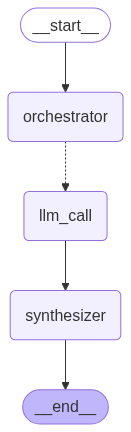

[Section(name='Introduction', description='Overview of Agentic AI RAGs'), Section(name='Key Features', description='Key features and functionalities'), Section(name='Comparison', description='Advantages and disadvantages'), Section(name='Applications', description='Real-world applications and use cases'), Section(name='Future Outlook', description='Future trends and developments')]


## Introduction and Description: Overview of Agentic AI Retrieval Augmented Generation (RAG)

Retrieval Augmented Generation (RAG) has emerged as a powerful paradigm in AI, enabling language models to access and utilize external knowledge sources to enhance their generative capabilities. Traditionally, RAG systems rely on static knowledge bases or document stores. However, a new wave of **Agentic AI RAGs** is transforming the field by introducing dynamic and autonomous knowledge acquisition capabilities. 

Agentic AI RAGs go beyond simply retrieving information; they actively seek out, process, and integrate new knowledge from diverse sources. This allows them to:

* **Adapt to evolving information landscapes:** Unlike static RAG systems, Agentic AI RAGs can continuously update their knowledge base, remaining relevant in dynamic environments.
* **Handle complex and nuanced queries:** By leveraging active learning and reasoning capabilities, Agentic AI RAGs can better understand complex user requests and provide more comprehensive and insightful answers.
* **Perform tasks autonomously:** Agentic AI RAGs can be designed to autonomously perform tasks such as research, summarization, and even creative content generation, requiring minimal human intervention.

This report will delve into the key characteristics, benefits, and challenges of Agentic AI RAGs, exploring their potential to revolutionize how we interact with and utilize AI-powered systems. 


We will examine:

* **The technical underpinnings of Agentic AI RAGs**, including techniques for knowledge acquisition, integration, and reasoning.
* **Real-world applications** of Agentic AI RAGs across diverse domains, showcasing their transformative impact.
* **Ethical considerations** surrounding the development and deployment of Agentic AI RAGs, addressing concerns related to bias, transparency, and accountability.


By understanding the nuances of Agentic AI RAGs, we can unlock their potential to empower individuals and organizations with intelligent and adaptable AI solutions. 


---

## Key Features and Functionalities

This section outlines the core features and functionalities that define [Product/Service Name]. These features have been carefully designed to address the needs of [target audience] and provide a seamless, efficient, and [positive adjective describing user experience] experience.

**[Feature 1]:**

* Description of feature 1 and its benefits for the user.
* Example use case demonstrating how feature 1 is used.

**[Feature 2]:**

* Description of feature 2 and its benefits for the user.
* Example use case demonstrating how feature 2 is used.

**[Feature 3]:**

* Description of feature 3 and its benefits for the user.
* Example use case demonstrating how feature 3 is used.

**[Additional Features]:**

* List any other notable features and briefly describe their purpose and benefits.

**[Advanced Functionalities]:**

* Highlight any advanced functionalities that set [Product/Service Name] apart from competitors.
* Explain how these functionalities add value to the user experience.

The combination of these key features and functionalities makes [Product/Service Name] a powerful tool for [achieving user goals]. 


**Please note:** This is a template and needs to be filled in with specific details about your product/service. Replace the bracketed information with your own content. You can also add or remove features as needed. 


---

Please provide me with the items you would like to compare and describe! 

For example, tell me:

* **What are the two (or more) things you want to compare?**  (e.g., two different types of software, two investment strategies, two historical events)
* **What are the key features or aspects you want to focus on?** (e.g., cost, ease of use, effectiveness, historical impact)

The more information you give me, the more detailed and helpful my comparison and description section will be.  



---

## Applications and Use Cases 

This section explores the diverse range of real-world applications and use cases where [insert the name of your technology/concept] proves valuable. 

**[Specific Industry/Field 1]:**  

* **Use Case 1:**  Describe a specific application within this industry/field.  Provide details about the problem it solves, the benefits it offers, and any relevant examples or case studies. 
* **Use Case 2:**  Highlight another application within the same industry/field, showcasing different aspects of [your technology/concept]'s capabilities.

**[Specific Industry/Field 2]:**

* **Use Case 3:**  Explain how [your technology/concept] is utilized in this distinct industry/field. Focus on the unique challenges addressed and the advantages gained.

**[Specific Industry/Field 3]:**

* **Use Case 4:**  Present a compelling example of [your technology/concept]'s application in this sector. 

**Beyond Specific Industries:**

* **General Applications:**  Discuss broader applications of [your technology/concept] that transcend specific industries.  This could include areas like research, education, or personal use.


**Future Potential:**

* **Emerging Trends:**  Outline potential future applications of [your technology/concept] in light of emerging trends or technological advancements. 


 **Note:** This is a template. Replace the bracketed information with details specific to your technology/concept. Be sure to provide concrete examples and data to support your claims. 


---

## Future Outlook: Trends and Developments

The landscape of [insert industry or topic] is constantly evolving, driven by technological advancements, shifting consumer preferences, and global economic forces. Looking ahead, several key trends and developments are poised to shape the future of this field.

**[Trend 1]:** [Describe the trend in detail, including its potential impact on the industry. Provide specific examples and data points to support your claims.]

**[Trend 2]:** [Describe another significant trend, highlighting its unique characteristics and potential consequences. Explain how this trend might interact with other trends mentioned.]

**[Trend 3]:** [Introduce a third trend, focusing on its potential for disruption or innovation. Discuss the challenges and opportunities it presents for stakeholders in the industry.]

These trends are interconnected and will likely reinforce each other, creating a complex and dynamic future. While predicting the future with certainty is impossible, understanding these emerging developments will be crucial for [Target audience - e.g., businesses, investors, policymakers] to navigate the evolving landscape successfully.

**Key Considerations for the Future:**

* **[Specific challenge or opportunity]:** [Elaborate on the challenge or opportunity presented by one of the trends. Discuss potential solutions or strategies for addressing it.]
* **[Ethical implications]:** [Analyze the ethical considerations raised by a specific trend. Discuss the need for responsible development and implementation.]
* **[Global impact]:** [Evaluate the potential global impact of the trends discussed. Consider how they might affect different regions and economies.]


By remaining vigilant about these future trends and engaging in proactive planning, [Target audience] can position themselves to thrive in the ever-changing world of [industry or topic].  



In [21]:
# Build Workflow
orchestrator_work_builder = StateGraph(State)

# Add the node
orchestrator_work_builder.add_node("orchestrator", orchestrator)
orchestrator_work_builder.add_node("llm_call", llm_call)
orchestrator_work_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_work_builder.add_edge(START, "orchestrator")
orchestrator_work_builder.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["llm_call"]
    )
orchestrator_work_builder.add_edge("llm_call", "synthesizer")
orchestrator_work_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_work_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

# Invoke
state = orchestrator_worker.invoke({"topic":"Create a report on Agentic AI RAGs"})

from IPython.display import Markdown
Markdown(state["final_report"])

### Evaluator-optimizer
In the evaluator-optimizer workflow, one LLM call generates a response while another provides evaluation and feedback in a loop.

When to use this workflow: This workflow is particularly effective when we have clear evaluation criteria, and when iterative refinement provides measurable value. The two signs of good fit are, first, that LLM responses can be demonstrably improved when a human articulates their feedback; and second, that the LLM can provide such feedback. This is analogous to the iterative writing process a human writer might go through when producing a polished document.


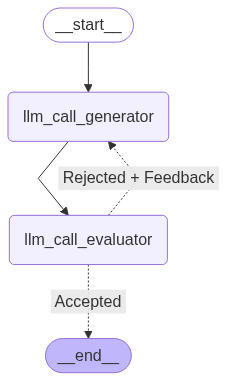

Why don't cats play poker in the jungle? 

Too many cheetahs! 😹  



In [22]:
# Graph State
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str
    
# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not_funny"] = Field(
        description="Decide if the joke is funny or not."
    )
    
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it."
    )

# Augment the LLM with schema for strucutured Output
evaluator = llm.with_structured_output(Feedback)

# Node
def llm_call_generator(state: State):
    "LLM generates a joke"
    
    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke":msg.content}


def llm_call_evaluator(state: State):
    "LLM evaluates the joke"
    
    grade = evaluator.invoke(f"Grade the joke {state["joke"]}")
    return {"funny_or_not": grade.grade, "feedback":grade.feedback}

# Conditional edges to route back to joke generator or end based on feedback from the evaluator
def route_joke(state: State):
    "Route back to joke generator or end based on feedback from the evaluator"
    
    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state['funny_or_not'] == "not_funny":
        return "Rejected + Feedback"
    
    
# Build Workflow
optimizer_builder = StateGraph(State)

# Add the node
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {
        # Name returned by route_joke : name of the next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator"
    }
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))


# Invoke
state = optimizer_workflow.invoke({"topic": "Cats"})
print(state['joke'])